# Train XGBoost model 

Use flattened data generated by `run/run_ml_prep.py`, where `run` is a string which indicates which round of processing was using (cuts/flattening technique), and hyperparameters found via the `optimise.ipynb` notebook.



In [1]:
import sys
sys.path.append("src/ml")

In [2]:

!pwd

/home/mu2ecrv/sgrant-ana/mu2e-cosmic


## Assemble dataset

run = "k" 

- 2026 MLPreprocess cuts with coinc start/end time
- All coincidences and all combinations of dt, each row is a coincidence
- Events with no coincidence have NaN CRV parameters 
- No start/end time cuts
- Duration as a feature

In [3]:
run = "k" 
from assemble import AssembleDataset
asm = AssembleDataset(run=run)
data = asm.assemble_dataset()

[LoadML] [OK] Initialised
[Load] [OK] Initialised with out_path=/home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/data/CRY_onspill-LH_aw/results.pkl
[Load] [OK] Initialised with out_path=/home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw
[Load] [OK] Successfully loaded results from /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/data/CE_mix2BB_onspill-LH_aw/results.pkl
[LoadML] [OK] Got full results
[Assemble] [OK] Loaded data
[Assemble] [OK] Initialised
[Assemble] [OK] Split data 70/15/15 (event-level grouping)
  Train: 1515614 coincidences
  Val:   324341 coincidences
  Test:  323573 coincidences


In [4]:
asm.check_dT_window_results()

,Metric,CRY,CE Mix
0,Total,20087,578368
1,Unvetoed,10,417011
2,Fraction [%],99.95,27.90


[Load] [OK] Initialised with out_path=test_out
[pyprint] [INFO] Initialised Print with verbose = False and precision = 1
[Plot] [INFO] Initialised
[Plot] [OK] 	Wrote /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/k/process/h1o_3x3_cuts_CRY.png


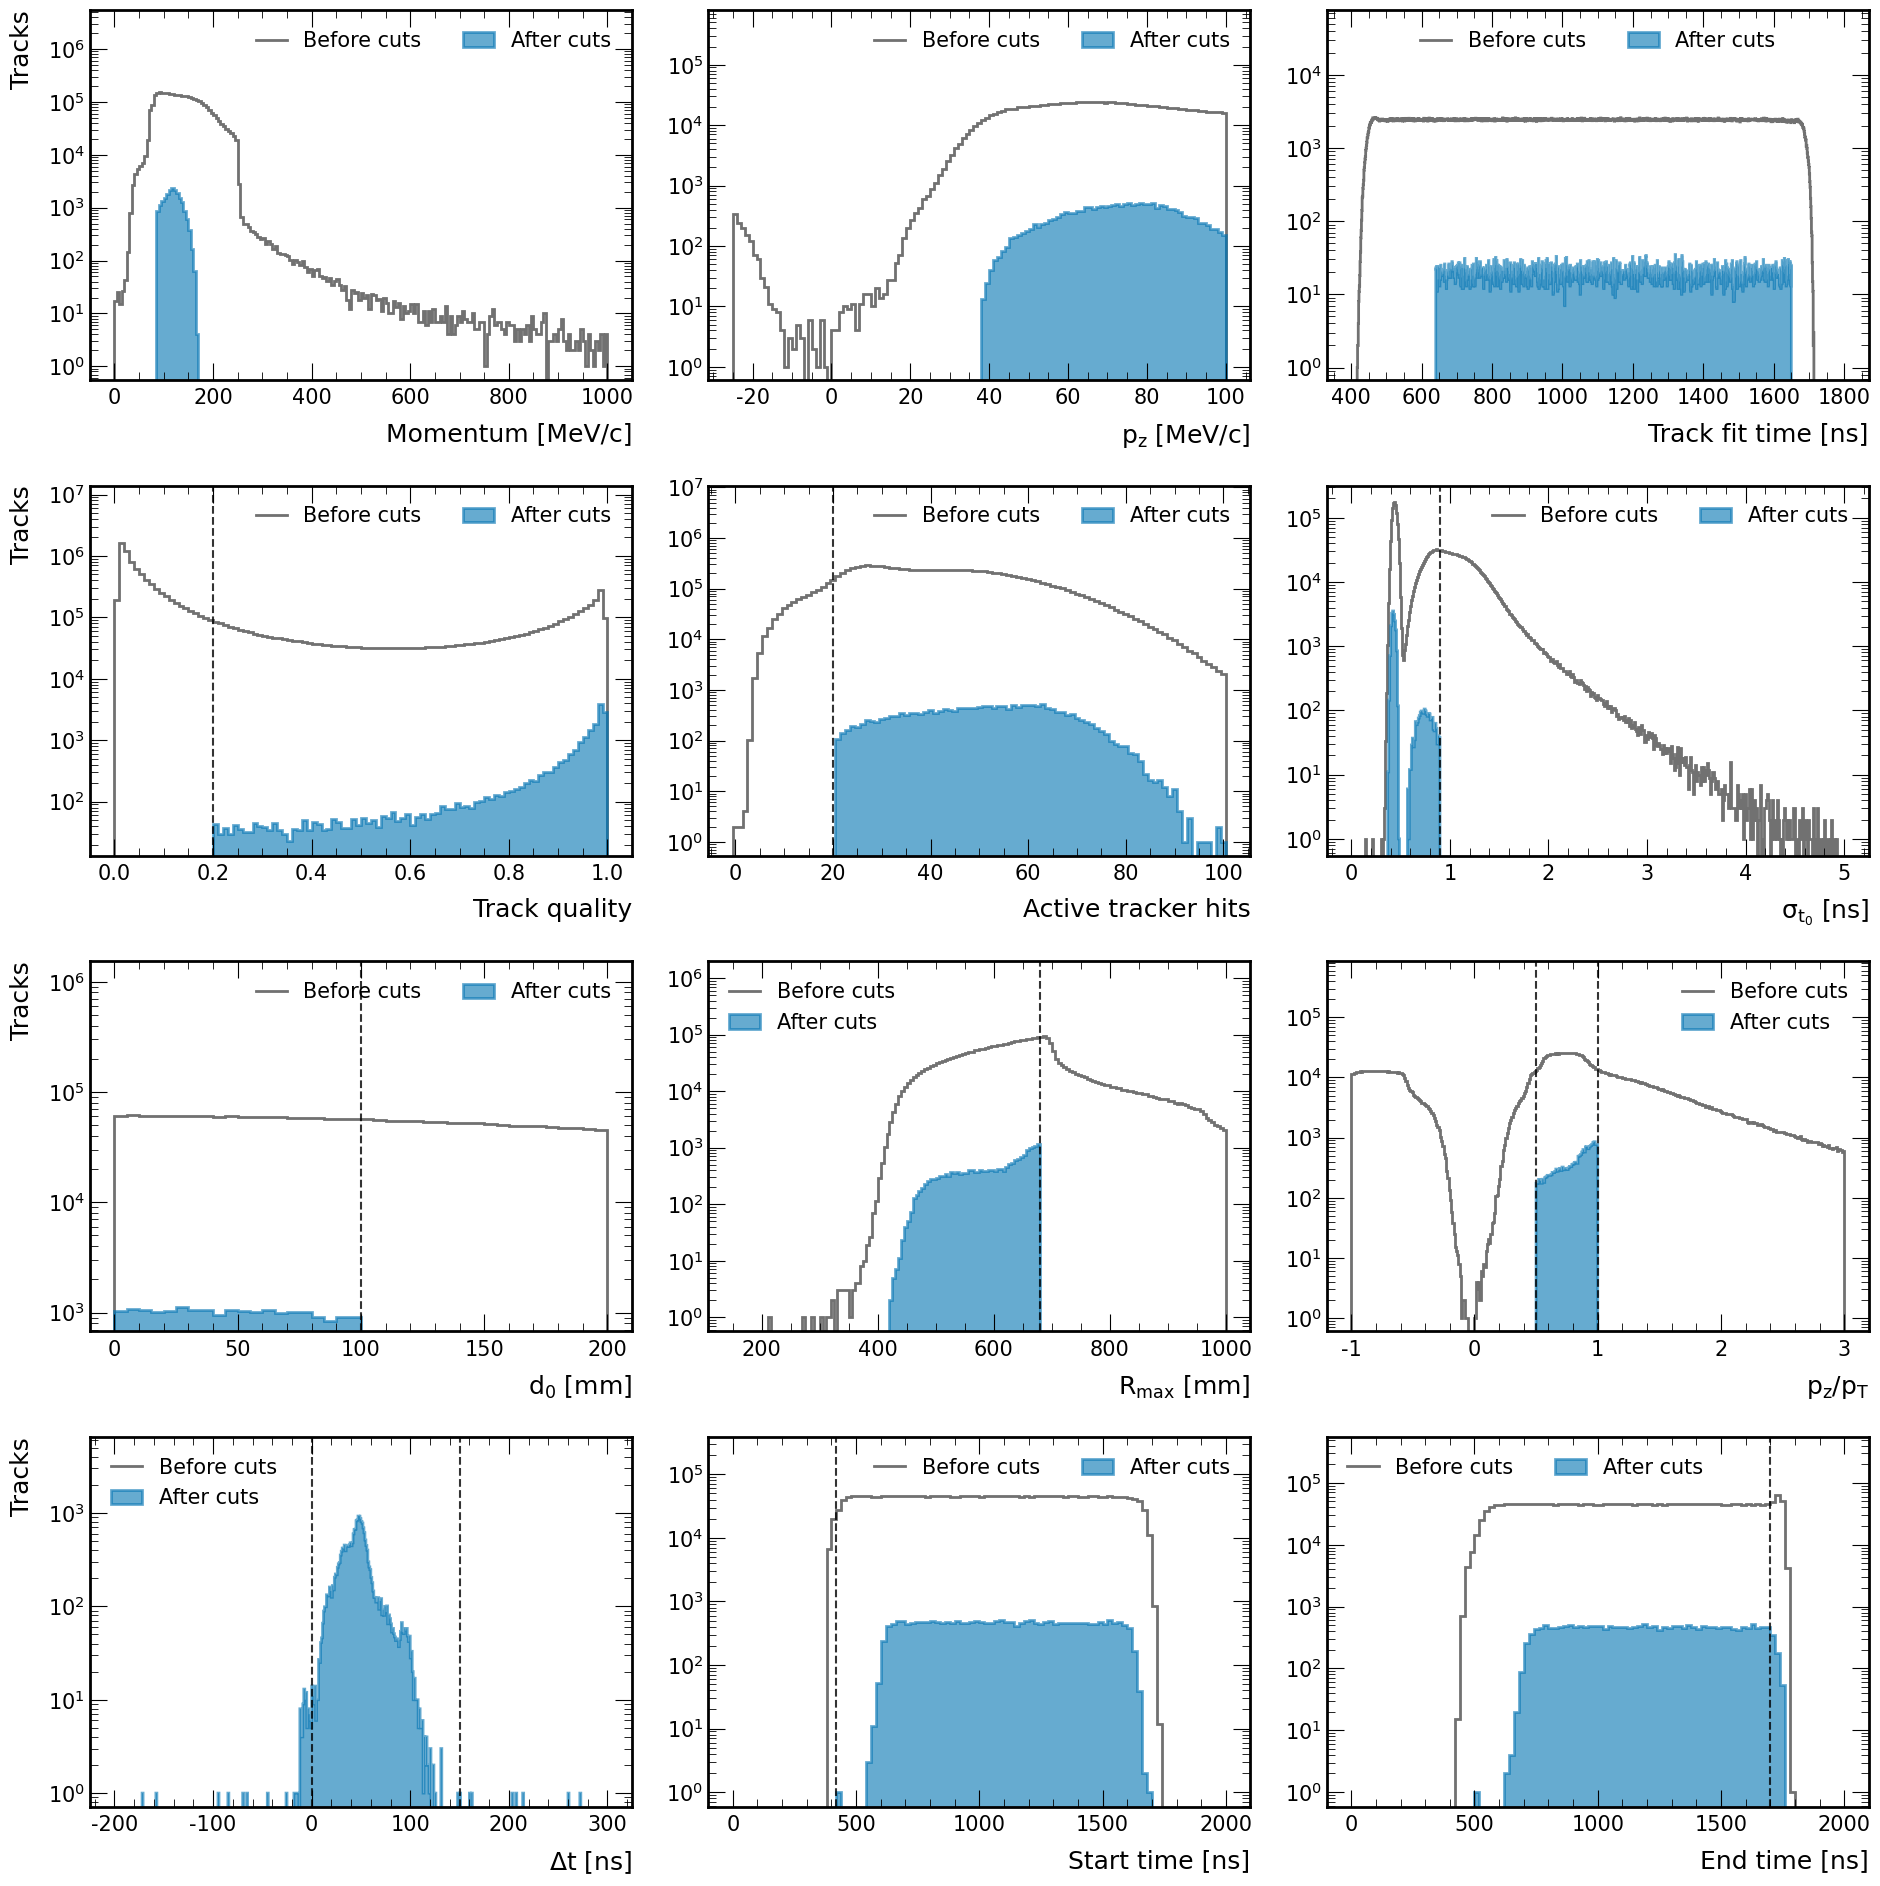

[Plot] [OK] 	Wrote /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/k/process/h1o_3x3_cuts_CE_mix.png


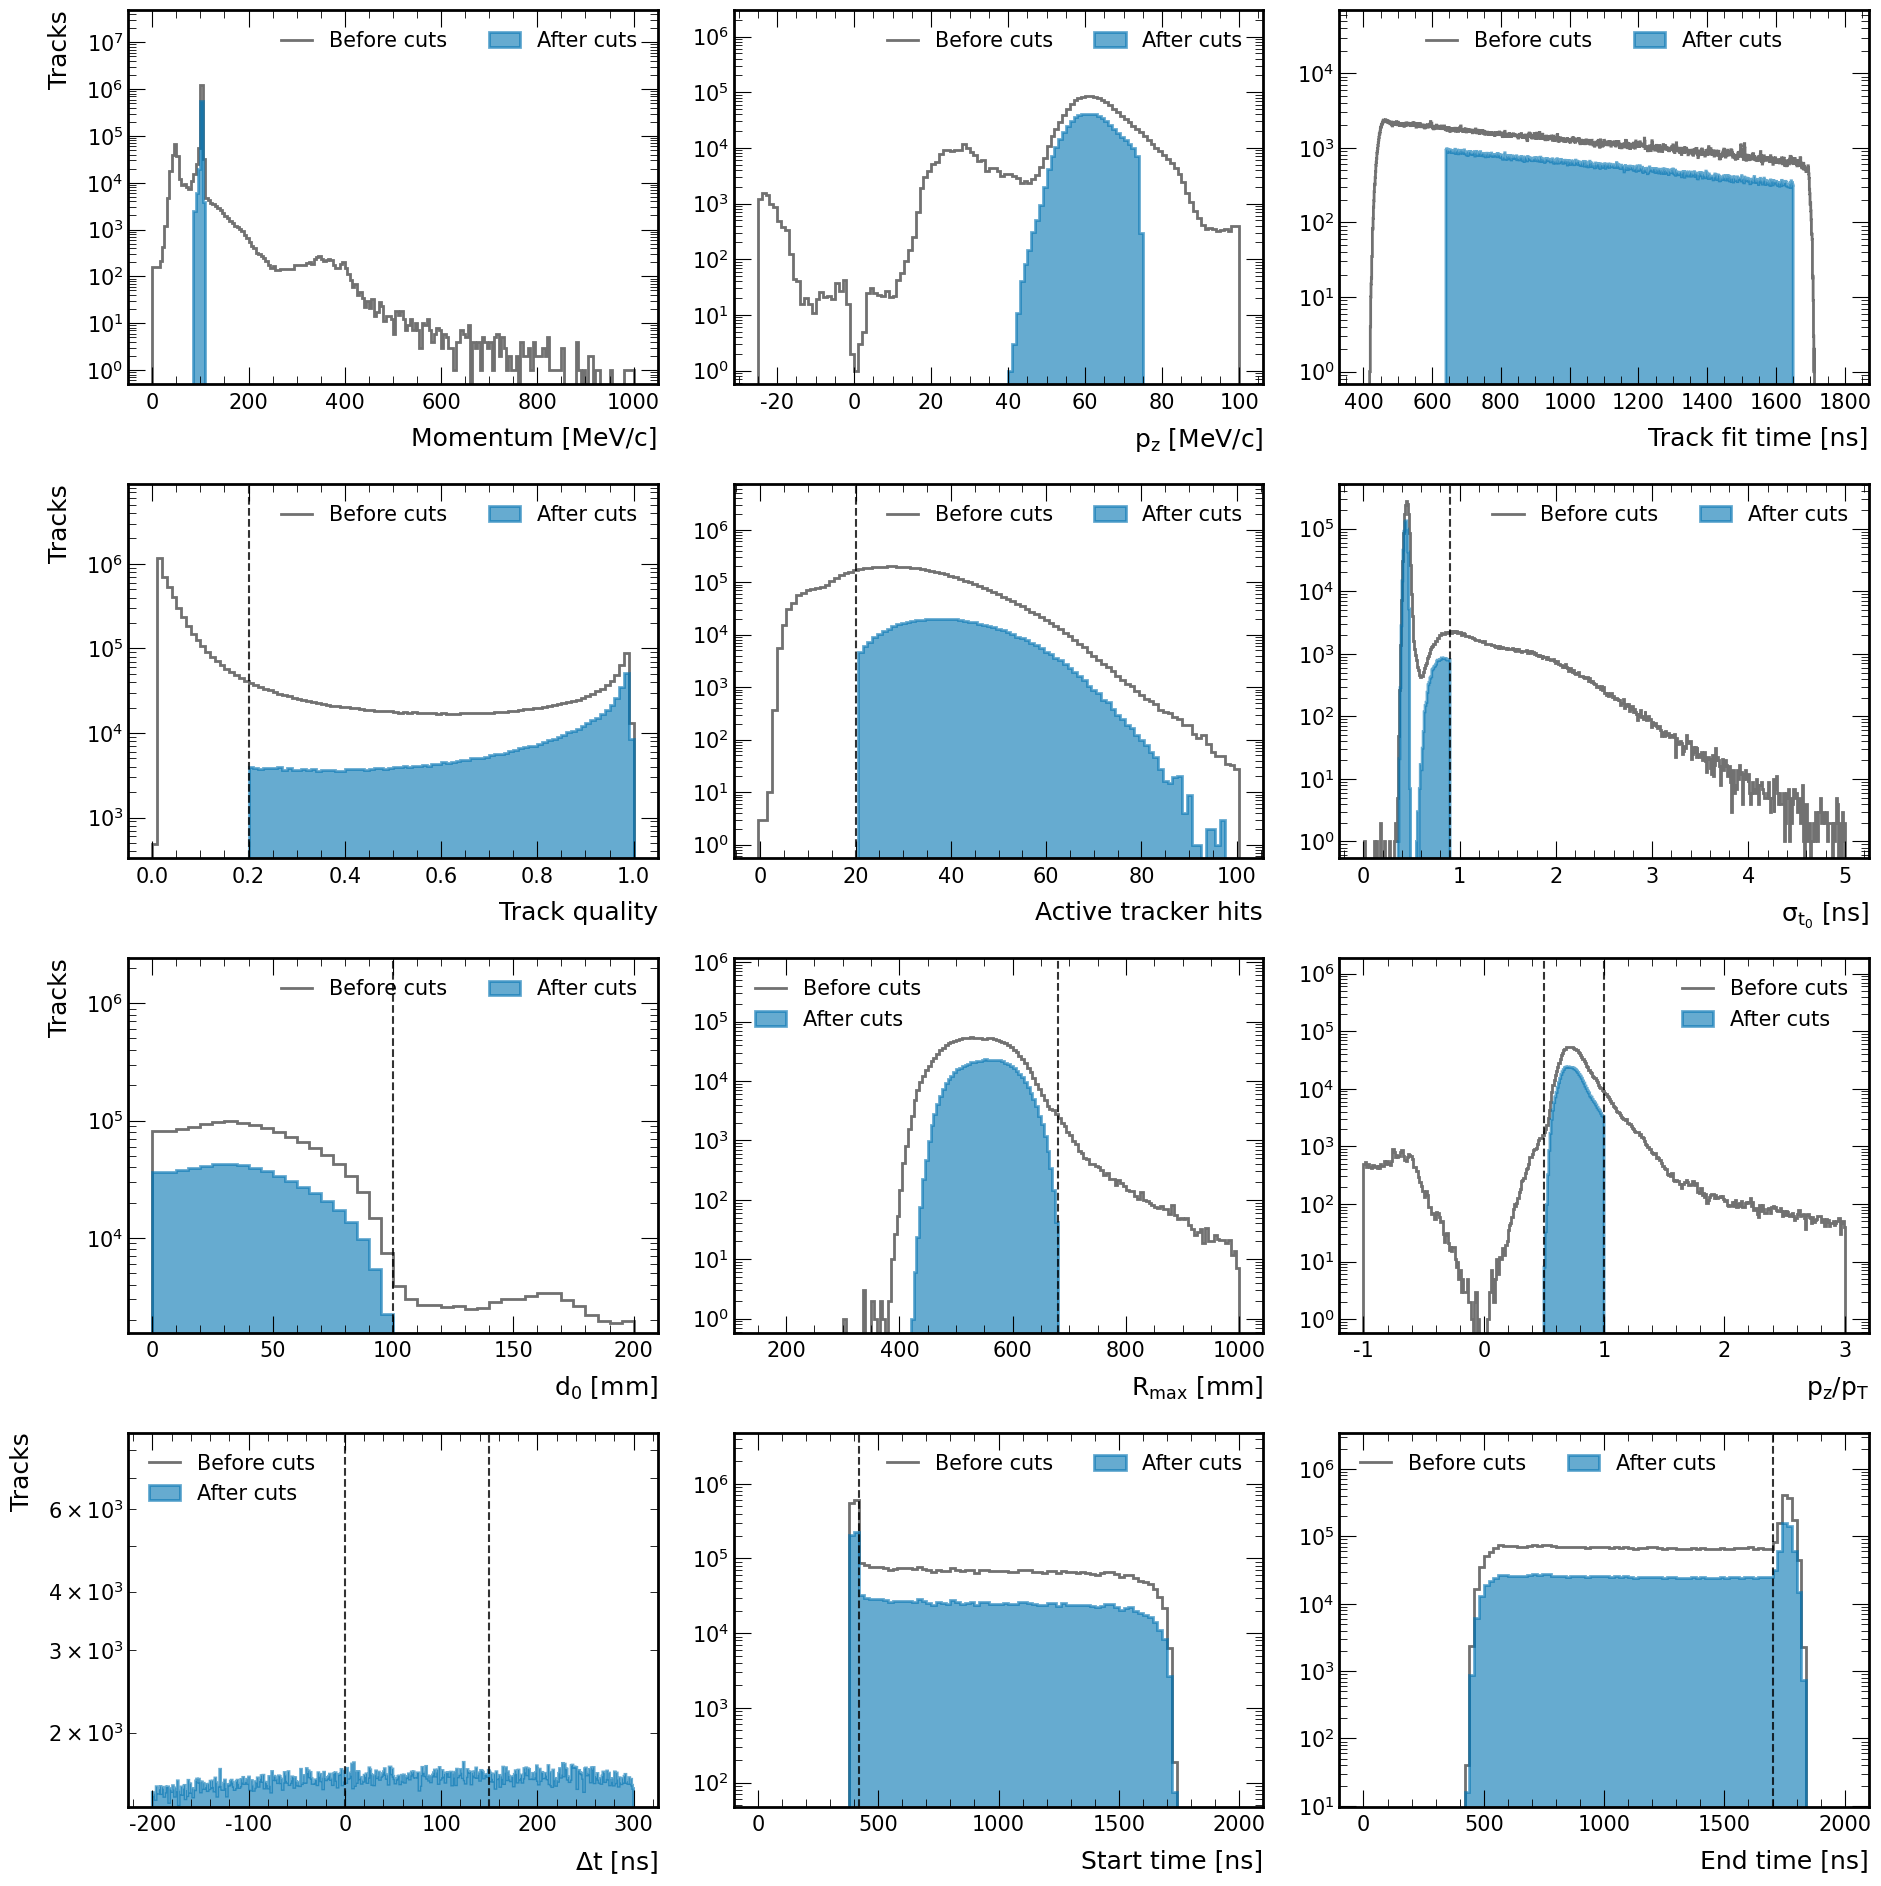

In [5]:
asm.draw_cuts()

[Assemble] [OK] Saved feature distributions to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/images/ml/k/process/h1o_2x4_crv_features.png


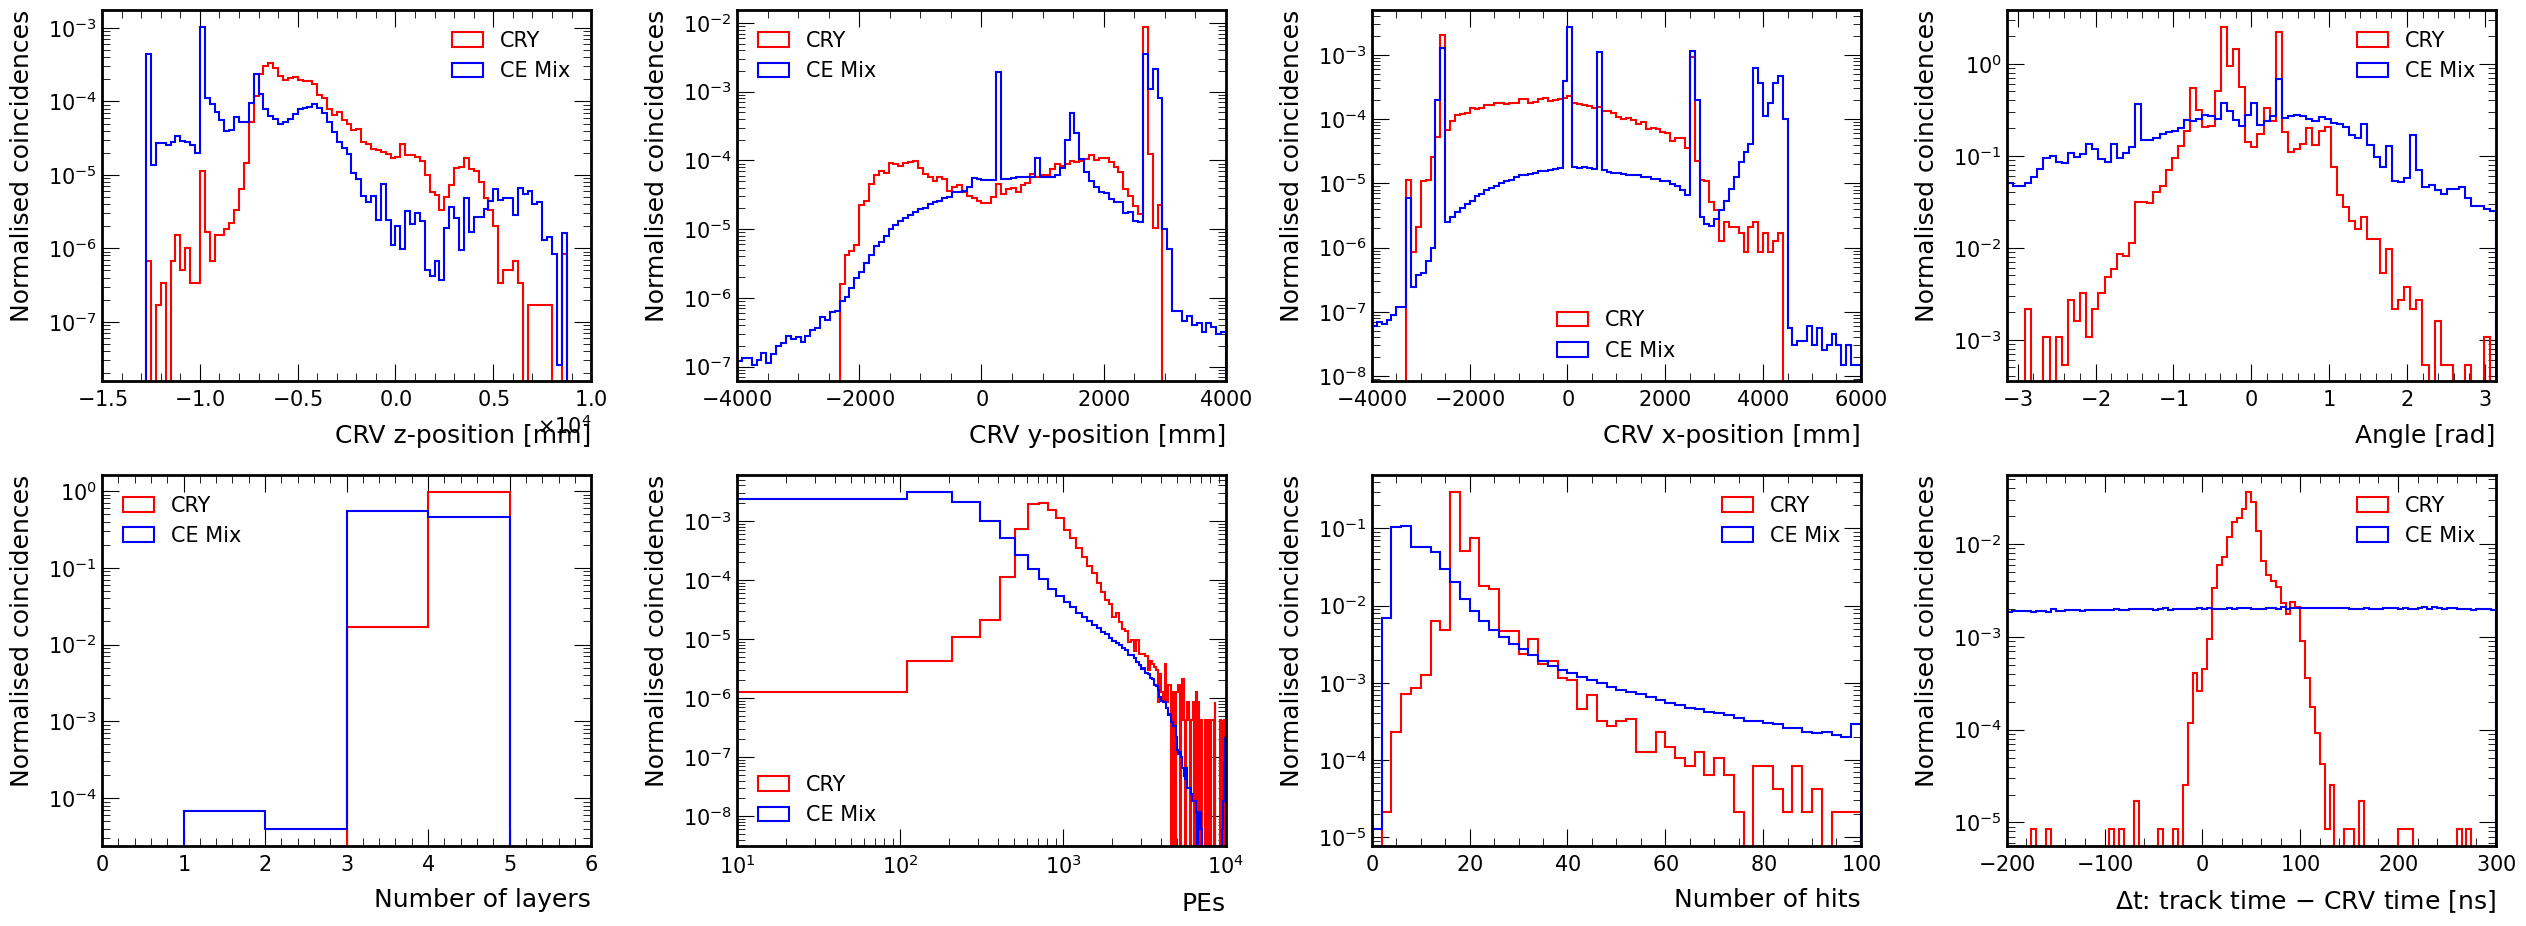

In [6]:
asm.draw_features()

In [7]:
data["df_full"]

,event,subrun,crv_x,crv_y,crv_z,PEs,dT,nHits,nLayers,angle,timeStart,timeEnd,sector,PEs_per_hit,t0,d0,tanDip,maxr,mom_mag,label
0,2650.0,98.0,-4.547474e-13,2684.661133,-7921.097656,90.724777,527.722271,4.0,3.0,0.727466,525.451538,587.951538,3.0,22.681194,1016.454419,42.117722,0.583941,617.263550,103.368034,0
1,1859.0,843.0,4.071482e+03,2862.049561,-9957.799805,285.257233,-805.731684,10.0,4.0,1.353849,1607.101807,1782.101807,4.0,28.525723,786.035162,32.673702,0.605967,602.773804,103.583145,0
2,2192.0,457.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1096.057591,8.055742,0.715509,539.576172,104.595360,0
3,556.0,411.0,6.362000e+02,1513.145508,-12567.080078,34580.207031,-397.368187,1899.0,4.0,-1.526525,412.966553,1787.966553,5.0,18.209693,661.050758,24.049637,0.879215,526.783875,104.189644,0
4,2974.0,707.0,0.000000e+00,2731.275635,-12267.968750,240.338318,-22.465829,8.0,4.0,-3.002133,983.740662,1146.240723,3.0,30.042290,1019.720328,65.952957,0.743986,470.854187,104.093399,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2163523,3061.0,925.0,3.952777e+01,2711.051514,-7511.345703,131.810699,782.745075,12.0,3.0,-1.497381,742.005493,842.005493,3.0,10.984225,1500.949542,74.319374,0.665570,633.117065,104.378433,0
2163524,3076.0,722.0,0.000000e+00,2681.962402,-2549.654053,86.194878,-311.175052,5.0,3.0,3.386727,1285.348145,1447.848145,3.0,17.238976,983.938596,30.310881,0.856973,541.797424,104.623466,0
2163525,2061.0,331.0,0.000000e+00,2701.172852,-11403.797852,260.580322,678.858792,11.0,4.0,-0.721829,716.635193,891.635193,3.0,23.689120,1384.573697,65.948845,0.930326,555.570496,104.027061,0
2163526,2004.0,40.0,-2.573767e+03,-934.724060,-4733.690430,200.804611,-146.186658,12.0,3.0,-1.477709,1139.843506,1252.343506,1.0,16.733718,976.955921,28.302200,0.711944,516.766479,103.907005,0


In [8]:
import numpy as np
df_full = data["df_full"]
dur = df_full["timeEnd"] - df_full["timeStart"]
print(dur.describe())
print(f"inf count: {np.isinf(dur).sum()}")
print(f"nan count: {dur.isna().sum()}")

import numpy as np
for col in data["X_train"].columns:
    n_inf = np.isinf(data["X_train"][col]).sum()
    n_nan = data["X_train"][col].isna().sum()
    if n_inf > 0 or n_nan > 0:
        print(f"{col}: inf={n_inf}, nan={n_nan}")

# import numpy as np
# for col in data["X_train"].columns:
#     mx = data["X_train"][col].abs().max()
#     if mx > 1e300 or np.isinf(mx):
#         print(f"{col}: max abs = {mx}"


count    2.013591e+06
mean     3.614186e+02
std      4.579360e+02
min      3.750000e+01
25%      8.750000e+01
50%      1.375000e+02
75%      3.125000e+02
max      1.412500e+03
dtype: float64
inf count: 0
nan count: 149937
crv_x: inf=0, nan=105183
crv_y: inf=0, nan=105183
crv_z: inf=0, nan=105183
PEs: inf=0, nan=105183
dT: inf=0, nan=105183
nHits: inf=0, nan=105183
nLayers: inf=0, nan=105183
angle: inf=0, nan=105231
sector: inf=0, nan=105183


## Train model

- Use hyperparameters found via grid search optimisation in optimise.ipynb 
- 70/15/15 train/test/validate split 
- Threshold found with cross validation

Hyperparameters found c

In [9]:
best_hp = {
    "n_estimators": 200,
    "max_depth": 7,
    "learning_rate": 0.1,
    # "scale_pos_weight": 135,
}

[Train] [OK] Initialised
[Train] [INFO] CV training: 5 folds, tag=xgb_optimised
  Hyperparams: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}
[Train] [INFO] CV results (5 folds):
  Threshold:       0.0540 +/- 0.0214
  Veto efficiency: 99.929 +/- 0.000%
  Deadtime:        0.150 +/- 0.037%
  AUC:             0.999878
[Train] [INFO] Training final model on full train set...
[Train] [INFO] Training model: XGBClassifier
  Tag: xgb_optimised
  Random state: 42
  Scale features: False

[Train] [INFO]   Hyperparams: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}

[Train] [OK] Training complete!
[Validate] [OK] Initialised analyser for model: xgb_optimised
[Train] [INFO] Validation set metrics (threshold=0.0540):
  Veto efficiency: 100.000%
  Deadtime:        0.154%
[Train] [INFO] Test set metrics (threshold=0.0540):
  Veto efficiency: 99.804%
  Deadtime:        0.127%
[Train] [OK] XGBoost model saved to /home/mu2ecrv/sgrant-ana/mu2e-cosmic/output/ml/k/results/xgb_opti

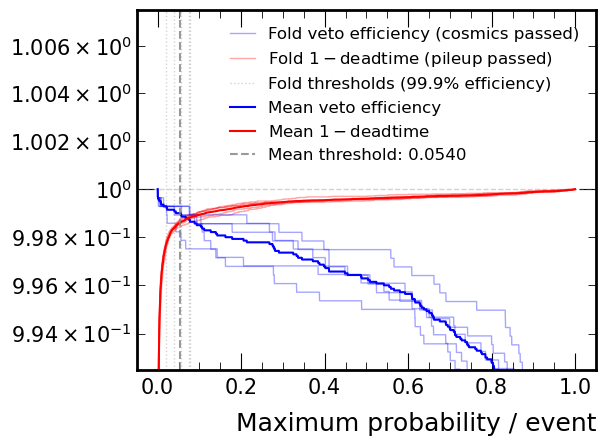

In [10]:
from train import Train
trn = Train(data, run=run) # , scale_features=False)
results = trn.train_cv(
    tag="xgb_optimised",
    n_folds=5, 
    save_output=True,
    **best_hp
)

In [11]:
results.keys()

dict_keys(['tag', 'model', 'feature_names', 'y_train', 'y_val', 'y_test', 'y_pred', 'y_proba', 'y_pred_val', 'y_proba_val', 'y_proba_train', 'X_val', 'X_test', 'scaler', 'metadata_val', 'metadata_test', 'cv_threshold', 'cv_threshold_std', 'cv_money_table', 'cv_metrics', 'val_money_table', 'test_money_table'])